# Saving and Loading the results of Toponymy

Once you've fit a Toponymy of your dataset, you may want to save the results and load them again later. Toponymy provides a dataclass called `TopicModel` that stores the final topic model information of a fitted toponymy. For example, suppose we've fit a toponymy on the 20-newsgroup data, as described in [Getting Started with Toponymy](https://toponymy.readthedocs.io/en/latest/basic_usage.html):


In [3]:
from sklearn import datasets
import matplotlib.pyplot as plt
import numpy as np
from sentence_transformers import SentenceTransformer
import pandas as pd
import pickle

model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

newsgroups_df = pd.read_parquet("hf://datasets/lmcinnes/20newsgroups_embedded/data/train-00000-of-00001.parquet")

embeddings = np.stack(newsgroups_df["embedding"].values)
projection = np.stack(newsgroups_df["map"].values)

document_metadata = newsgroups_df[['post','newsgroup']]

from toponymy.toponymy import Toponymy, ToponymyClusterer, KeyphraseBuilder
from toponymy.llm_wrappers import AzureAINamer
from pathlib import Path
if Path("topic_model.pkl").is_file():
    with open ('topic_model.pkl', 'rb') as f:
        toponymy = pickle.load(f)
else:
    clusterer = ToponymyClusterer(verbose=True, base_min_cluster_size=25)
    with open('cohere.txt', 'r') as file:
        api_key = file.read().strip()
    # Initialize Cohere wrapper  
    llm=AzureAINamer(
        api_key, 
        endpoint="https://azureaitimcuse5821437469.services.ai.azure.com/models",
        model="Cohere-command-r-08-2024",
    )
    
    toponymy = Toponymy(
        llm_wrapper=llm,
        text_embedding_model=model,
        clusterer=clusterer,
        keyphrase_builder=KeyphraseBuilder(ngram_range=(1,6), max_features=15_000),
        object_description="newsgroup posts",
        corpus_description="20-newsgroups dataset",
        exemplar_delimiters=["<EXAMPLE_POST>\n","\n</EXAMPLE_POST>\n\n"],
    )
    toponymy.fit(
        newsgroups_df["post"].str.strip().values,
        embedding_vectors=embeddings,
        clusterable_vectors=projection
    )

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## TopicModel class
A TopicModel object can be made from this topoynmy using `TopicModel.from_toponymy`. The toponymy object does not store any metadata about the input documents, but you can have that information stored in the TopicModel by passing a pandas dataframe as `document_df`.

In [4]:
from toponymy.serialization import TopicModel

topic_model = TopicModel.from_toponymy(
    toponymy,
    document_df=document_metadata
)
topic_model

TopicModel(n_samples=18170, n_topics=269)

A TopicModel stores
 * topic_df - A pandas dataframe containing topic metadata,
 * cluster_tree - A dictionary whose keys are clusters and values are their children,
 * cluster_layers - A list of sparse matrices, where the l-th matrix's ij-th entry contains the inclusion strength of document i in cluster (l,j),
 * embedding_vectors - The embedding vectors passed to the Toponymy,
 * reduced_vectors - The clusterable vectors passed to the Toponymy.

In addition, it has two property methods `topic_names` and `topic_name_vectors` that mirror the methods of the same name of Toponymy. 

For example, we can create a [datamapplot](https://github.com/TutteInstitute/datamapplot) using the `TopicModel`:

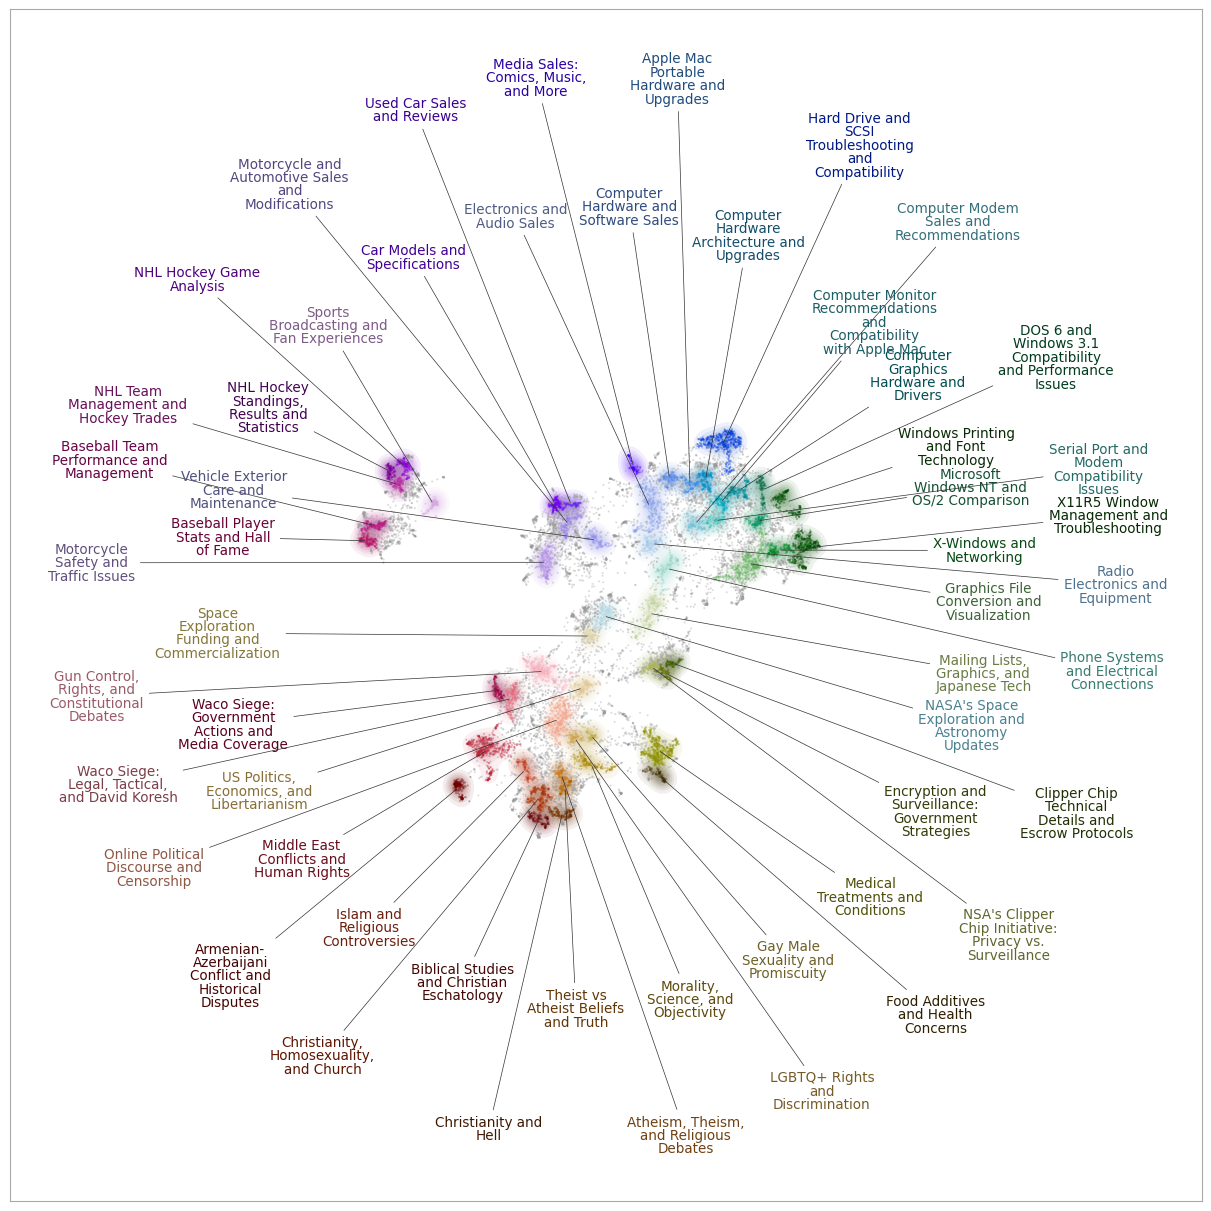

In [5]:
import datamapplot
fig = datamapplot.create_plot(
    topic_model.reduced_vectors,
    topic_model.topic_name_vectors[1],
)

## Saving to Disk

To save the TopicModel to disk, there are two choices
1. `TopicModel.to_file(path)` stores the topic model as a zip file,
2. `TopicModel.to_lance(path)` stores the topic model as a [LanceDB](https://lancedb.com/) folder.

For example:

In [6]:
topic_model.to_file('20ng-topicmodel.tm.zip')
new_model = TopicModel.from_file('20ng-topicmodel.tm.zip')
print(new_model)

topic_model.to_lance('20ng-topicmodel')
new_model = TopicModel.from_lance('20ng-topicmodel')
print(new_model)

TopicModel(n_samples=18170, n_topics=269)
TopicModel(n_samples=18170, n_topics=269)


Both of these save formats are compatible with the [thematic-search](https://github.com/kalebruscitti/thematic-search) package, which can be used to search through the results of your topic model. (See: [Toponymy Integration](https://thematic-search.readthedocs.io/en/latest/toponymy_integration.html) in the Thematic Search documentation.)